In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


In [3]:
DATASET_DIR = r"C:\Users\zeroh\OneDrive\Desktop\vv\violence_dataset"

IMG_SIZE = (224, 224)   # works well with most CNNs
BATCH_SIZE = 32


In [4]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 80% train, 20% validation
)


In [5]:
train_data = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)


Found 8851 images belonging to 2 classes.


In [6]:
val_data = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)


Found 2212 images belonging to 2 classes.


In [7]:
print(train_data.class_indices)


{'non_violence': 0, 'violence': 1}


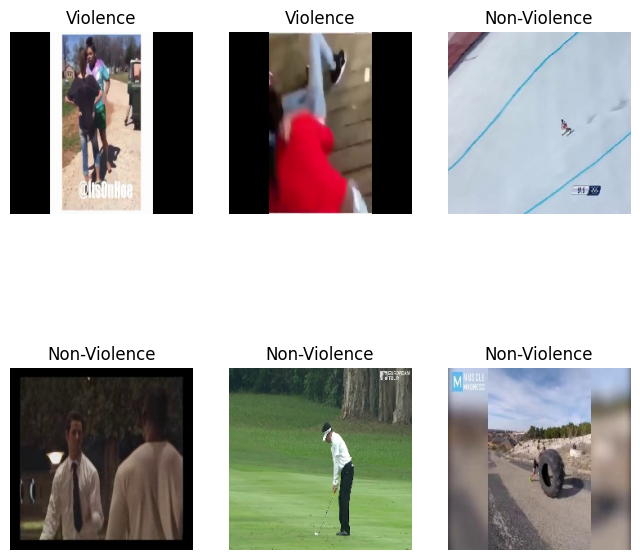

In [8]:
images, labels = next(train_data)

plt.figure(figsize=(8,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("Violence" if labels[i]==1 else "Non-Violence")
    plt.axis("off")
plt.show()


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.3,
    shear_range=0.2,
    brightness_range=[0.6,1.4],
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)


Found 8851 images belonging to 2 classes.
Found 2212 images belonging to 2 classes.


In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: 1.0574671445639188, 1: 0.9484569224174882}


In [12]:
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Phase 1

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)


In [13]:
from tensorflow.keras.metrics import Precision, Recall
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)


In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3)
]


In [15]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/20
277/277 [==============================] - 334s 1s/step - loss: 0.5045 - accuracy: 0.7535 - precision: 0.7706 - recall: 0.7580 - val_loss: 0.3236 - val_accuracy: 0.8784 - val_precision: 0.9342 - val_recall: 0.8276 - lr: 1.0000e-04
Epoch 2/20
277/277 [==============================] - 369s 1s/step - loss: 0.3600 - accuracy: 0.8400 - precision: 0.8534 - recall: 0.8410 - val_loss: 0.2714 - val_accuracy: 0.8969 - val_precision: 0.8889 - val_recall: 0.9194 - lr: 1.0000e-04
Epoch 3/20
277/277 [==============================] - 342s 1s/step - loss: 0.3169 - accuracy: 0.8626 - precision: 0.8727 - recall: 0.8656 - val_loss: 0.2576 - val_accuracy: 0.8978 - val_precision: 0.8976 - val_recall: 0.9099 - lr: 1.0000e-04
Epoch 4/20
277/277 [==============================] - 314s 1s/step - loss: 0.2920 - accuracy: 0.8755 - precision: 0.8862 - recall: 0.8763 - val_loss: 0.2572 - val_accuracy: 0.8951 - val_precision: 0.9230 - val_recall: 0.8739 - lr: 1.0000e-04
Epoch 5/20
277/277 [============

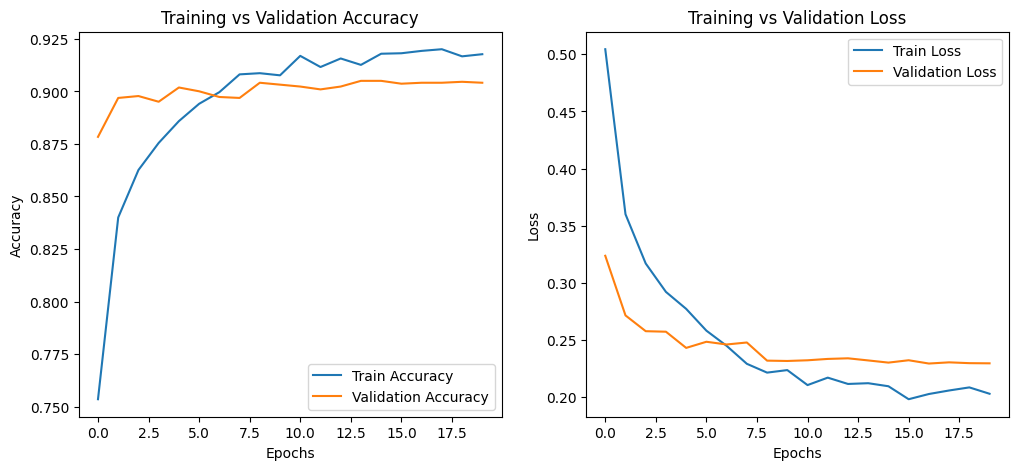

In [16]:
# Accuracy graph
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


In [17]:
model.save("violence_cnn_mobilenetv2.h5")


In [1]:
import cv2
import numpy as np
import tensorflow as tf
import os
import time
from datetime import datetime
from collections import deque

# Load model
model = tf.keras.models.load_model("violence_cnn_mobilenetv2.h5")

IMG_SIZE = 224
THRESHOLD = 0.6
VOTE_FRAMES = 10
COOLDOWN = 5  # seconds between saves

pred_queue = deque(maxlen=VOTE_FRAMES)

SAVE_FOLDER = "violence_frames"
os.makedirs(SAVE_FOLDER, exist_ok=True)

last_saved_time = 0  # track last save timestamp

cap = cv2.VideoCapture(0)
print("✅ Webcam started. Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Preprocess
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)[0][0]
    pred_queue.append(pred)
    avg_pred = np.mean(pred_queue)

    current_time = time.time()

    if avg_pred > THRESHOLD:
        label = "VIOLENCE"
        color = (0, 0, 255)

        # Save only if cooldown passed
        if current_time - last_saved_time > COOLDOWN:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f"{SAVE_FOLDER}/violence_{timestamp}.jpg"
            cv2.imwrite(filename, frame)
            print(f"📸 Saved: {filename}")
            last_saved_time = current_time

    else:
        label = "NON-VIOLENCE"
        color = (0, 255, 0)

    text = f"{label} ({avg_pred:.2f})"
    cv2.putText(frame, text, (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    cv2.imshow("Violence Detection (Webcam)", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


✅ Webcam started. Press 'q' to quit.


In [3]:
import cv2
import numpy as np
import tensorflow as tf
import os
import time
from datetime import datetime
from collections import deque

# ---------------------------
# CONFIGURATION
# ---------------------------
MODEL_PATH = "violence_cnn_mobilenetv2.h5"
VIDEO_PATH = "V_121.mp4"   # <-- Your downloaded video
IMG_SIZE = 224
THRESHOLD = 0.70
VOTE_FRAMES = 15
COOLDOWN = 5  # seconds between saves
SAVE_FOLDER = "violence_frames"

# ---------------------------
# LOAD MODEL
# ---------------------------
print("🔄 Loading model...")
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model Loaded Successfully!")

# ---------------------------
# SETUP SAVE FOLDER
# ---------------------------
os.makedirs(SAVE_FOLDER, exist_ok=True)

# ---------------------------
# LOAD VIDEO
# ---------------------------
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    print("❌ Error opening video file")
    exit()

print("🎬 Video Started. Press 'q' to quit.")

# ---------------------------
# VARIABLES
# ---------------------------
pred_queue = deque(maxlen=VOTE_FRAMES)
last_saved_time = 0

# ---------------------------
# MAIN LOOP
# ---------------------------
while True:
    ret, frame = cap.read()

    # If video ends → restart
    if not ret:
        print("🔁 Restarting video...")
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        continue

    original_frame = frame.copy()

    # Resize for model
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict
    pred = model.predict(img, verbose=0)[0][0]
    pred_queue.append(pred)
    avg_pred = np.mean(pred_queue)

    current_time = time.time()

    # Classification
    if avg_pred > THRESHOLD:
        label = "VIOLENCE DETECTED"
        color = (0, 0, 255)

        # Save frame with cooldown
        if current_time - last_saved_time > COOLDOWN:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f"{SAVE_FOLDER}/violence_{timestamp}.jpg"
            cv2.imwrite(filename, original_frame)
            print(f"📸 Saved: {filename}")
            last_saved_time = current_time

    else:
        label = "NON-VIOLENCE"
        color = (0, 255, 0)

    # ---------------------------
    # DISPLAY SECTION
    # ---------------------------

    # Label
    text = f"{label} ({avg_pred:.2f})"
    cv2.putText(frame, text, (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    # Confidence Bar
    bar_x, bar_y = 20, 70
    bar_width, bar_height = 300, 20
    filled_width = int(bar_width * avg_pred)

    cv2.rectangle(frame,
                  (bar_x, bar_y),
                  (bar_x + bar_width, bar_y + bar_height),
                  (200, 200, 200), 2)

    cv2.rectangle(frame,
                  (bar_x, bar_y),
                  (bar_x + filled_width, bar_y + bar_height),
                  color, -1)

    cv2.putText(frame, "Confidence",
                (bar_x, bar_y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6, (255, 255, 255), 1)

    cv2.imshow("🔥 AI Violence Detection - Test Mode", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# ---------------------------
# CLEANUP
# ---------------------------
cap.release()
cv2.destroyAllWindows()

🔄 Loading model...
✅ Model Loaded Successfully!
🎬 Video Started. Press 'q' to quit.
🔁 Restarting video...
🔁 Restarting video...
